In [2]:
import torch
import numpy as np
import librosa
import glob
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings

# ==========================================
# 1. mfccによる特徴量抽出
# ==========================================

def extract_mfcc_vector_from_pt(audio, sr=16000, n_mfcc=20): # 次元数を20程度に落とす
    """
    Method 2 (王道): MFCCによる音色抽出
    """
    if isinstance(audio, torch.Tensor):
        y = audio.numpy()
    else:
        y = audio

    # 1. MFCC計算
    # n_mfcc=20 は音色認識のデファクトスタンダード
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

    # 2. 第0係数（パワー）を捨てる
    # 音量の情報を消して、音色の形だけにする
    mfcc = mfcc[1:, :]

    # 3. 時間平均
    # 無音区間を除外
    rms = librosa.feature.rms(y=y)
    is_active = (rms > 1e-4).squeeze()

    if np.sum(is_active) > 0:
        vector = np.mean(mfcc[:, is_active], axis=1)
    else:
        vector = np.zeros(n_mfcc - 1)

    # 4. 正規化 (Standardization)
    # MFCCは次元ごとにスケールが違うので、最大値合わせではなく標準化が吉
    # ただしここでは簡易的にそのまま返す（PCA側でScaleされることを期待）

    return vector

# これを使って analyze_dataset_pca を書き換えて実行してください

# ==========================================
# 2. データセット読み込み & 解析プロセス
# ==========================================
def analyze_dataset_pca(pt_dir, sr=16000, n_mfcc=20, n_fft=2048, hop_length=64):

    # .ptファイルを検索
    pt_files = glob.glob(os.path.join(pt_dir, "*.pt"))
    print(f"Found {len(pt_files)} files in {pt_dir}")

    features = []
    labels = []

    print("Extracting harmonic features...")
    for pt_path in tqdm(pt_files):
        try:
            # Load Data
            data = torch.load(pt_path)

            # 必要なデータを取り出す
            audio = data['audio'] # [Time]
            f0 = data['f0']       # [Time, 1]
            instrument_name = data['instrument_name']

            # 倍音ベクトル抽出 (Method 1)
            # ここで前処理時と同じhop_lengthを指定することが重要！
            vec = extract_mfcc_vector_from_pt(audio, sr=sr, n_mfcc=n_mfcc)

            features.append(vec)
            labels.append(instrument_name)

        except Exception as e:
            print(f"Error loading {pt_path}: {e}")
            continue

    return np.array(features), np.array(labels)

# ==========================================
# 3. PCA実行と可視化
# ==========================================
def run_pca_visualization(X, y):
    if len(X) == 0:
        print("No features to analyze.")
        return

    # PCA
    pca = PCA(n_components=2)
    latent_z = pca.fit_transform(X)

    print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")
    print(f"PC1: {pca.explained_variance_ratio_[0]:.2%}")
    print(f"PC2: {pca.explained_variance_ratio_[1]:.2%}")

    # Plot 1: 散布図 (潜在空間)
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=latent_z[:, 0], y=latent_z[:, 1], hue=y, style=y, s=80, alpha=0.8)
    plt.title("Latent Space of Harmonic Structures (Method 1)")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, alpha=0.3)
    plt.legend(title='Instrument')
    plt.show()

    # Plot 2: 固有ベクトルの意味 (ローディング)
    plt.figure(figsize=(12, 5))
    plt.plot(pca.components_[0], label='PC1 (Axis X)', linewidth=2)
    plt.plot(pca.components_[1], label='PC2 (Axis Y)', linewidth=2, linestyle='--')
    plt.title("What do the axes represent?")
    plt.xlabel("Harmonic Order (1st to 64th)")
    plt.ylabel("Weight")
    plt.legend()
    plt.grid(True)
    plt.show()

# ==========================================
# 実行ブロック
# ==========================================
# 前処理の設定に合わせて変更してください
SR = 16000
N_FFT = 2048
HOP_LENGTH = 64  # extract_featuresで指定した値と合わせてください！
OUTPUT_DIR = "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data" # .ptファイルがある場所

# 1. 解析実行
X, y = analyze_dataset_pca(OUTPUT_DIR, sr=SR, n_mfcc=20, n_fft=N_FFT, hop_length=HOP_LENGTH)

# 2. 可視化
run_pca_visualization(X, y)

Found 968 files in /content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data
Extracting harmonic features...


  1%|          | 10/968 [01:41<2:42:32, 10.18s/it]


KeyboardInterrupt: 

Dataset Shape: (968, 19)

[Metric 1] Silhouette Score (Original Space): 0.2297
  -> (目安: 0.5以上=良, 0.2周辺=重なりあり, 0以下=失敗)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



[Metric 2] Linear Classification Accuracy: 95.88%
  -> (もし低いなら、倍音抽出自体がうまくいっていない)


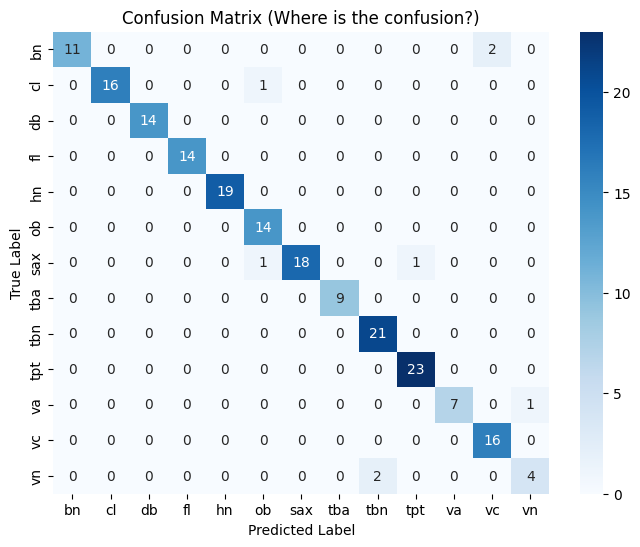

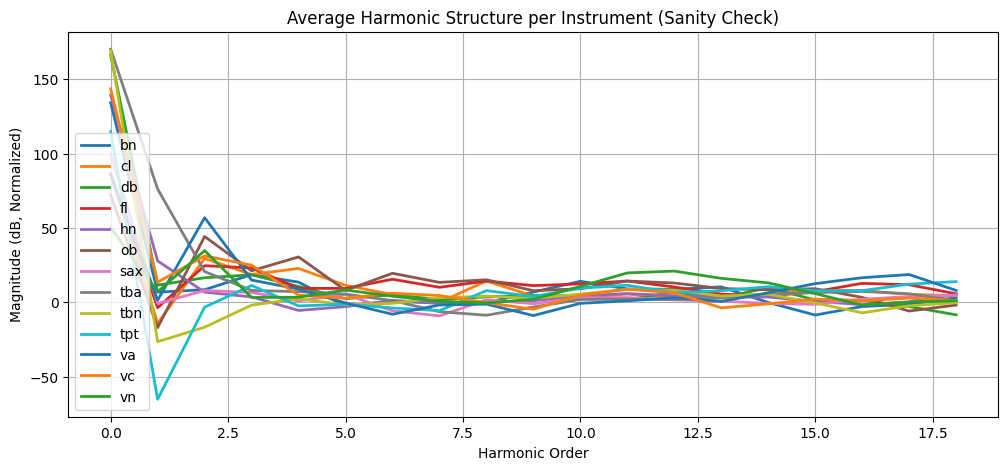

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def evaluate_features(X, y):
    """
    抽出された特徴量(X)とラベル(y)の品質を評価する
    """
    print(f"Dataset Shape: {X.shape}")

    # --- 1. シルエット係数 (PCA空間ではなく、元の64次元空間で測る) ---
    # データが多いと重いので、最大1000サンプルで計算
    if len(X) > 1000:
        idx = np.random.choice(len(X), 1000, replace=False)
        X_sub, y_sub = X[idx], y[idx]
    else:
        X_sub, y_sub = X, y

    sil_score = silhouette_score(X_sub, y_sub)
    print(f"\n[Metric 1] Silhouette Score (Original Space): {sil_score:.4f}")
    print("  -> (目安: 0.5以上=良, 0.2周辺=重なりあり, 0以下=失敗)")

    # --- 2. 線形分類精度 (Logistic Regression) ---
    # データを分割
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 簡易学習
    clf = LogisticRegression(max_iter=1000, multi_class='auto')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\n[Metric 2] Linear Classification Accuracy: {acc:.2%}")
    print("  -> (もし低いなら、倍音抽出自体がうまくいっていない)")

    # 混同行列 (どの楽器とどの楽器が間違えられているか)
    cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y), cmap='Blues')
    plt.title("Confusion Matrix (Where is the confusion?)")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    # --- 3. 「平均倍音ベクトル」の可視化 (最重要デバッグ) ---
    # 楽器ごとの「平均的な64次元ベクトル」を描画する。
    # もしこれが全部同じ形に見えるなら、抽出処理にバグがある。

    unique_labels = np.unique(y)
    plt.figure(figsize=(12, 5))

    for label in unique_labels:
        # その楽器のデータだけを取り出す
        indices = np.where(y == label)[0]
        vectors = X[indices]

        # 平均ベクトル
        mean_vector = np.mean(vectors, axis=0)
        plt.plot(mean_vector, label=label, linewidth=2)

    plt.title("Average Harmonic Structure per Instrument (Sanity Check)")
    plt.xlabel("Harmonic Order")
    plt.ylabel("Magnitude (dB, Normalized)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- 実行 ---
# X, y は前回の analyze_dataset_pca で取得したものを使ってください
evaluate_features(X, y)

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import torch
import glob
import os
from tqdm import tqdm

def evaluate_overlap_pitch(pt_dir, f0_min=261.6, f0_max=523.3, n_mfcc=19):
    """
    指定された音域（f0_min ~ f0_max）に含まれるデータだけで分類テストを行う
    これにより「音域によるカンニング」を排除して実力を測る
    """
    print(f"Loading data with f0 range: {f0_min:.1f} Hz - {f0_max:.1f} Hz...")

    features = []
    labels = []

    pt_files = glob.glob(os.path.join(pt_dir, "*.pt"))

    for pt_path in tqdm(pt_files):
        try:
            data = torch.load(pt_path)

            # f0の平均値を計算
            f0 = data['f0'].numpy().flatten()
            # 0やNaNを除外して平均をとる
            valid_f0 = f0[f0 > 40]
            if len(valid_f0) == 0: continue
            mean_f0 = np.mean(valid_f0)

            # 指定範囲外ならスキップ (ここが重要！)
            if mean_f0 < f0_min or mean_f0 > f0_max:
                continue

            # 特徴量 (MFCC) の読み込み
            # (ここでは簡易的に、保存されているデータから再抽出するか、
            #  あるいは前のリストがあればそれを使いますが、今回はファイルを読み直す想定)
            audio = data['audio'].numpy()

            # --- MFCC抽出 (前の関数と同じロジック) ---
            mfcc = librosa.feature.mfcc(y=audio, sr=16000, n_mfcc=n_mfcc+1)
            mfcc = mfcc[1:, :] # 第0係数削除
            # RMSによる無音除去
            rms = librosa.feature.rms(y=audio)
            is_active = (rms > 1e-4).squeeze()
            if np.sum(is_active) > 0:
                vector = np.mean(mfcc[:, is_active], axis=1)
            else:
                vector = np.zeros(n_mfcc)
            # ---------------------------------------

            features.append(vector)
            labels.append(data['instrument_name'])

        except Exception:
            continue

    features = np.array(features)
    labels = np.array(labels)

    print(f"\nData filtered. Remaining samples: {len(features)}")

    if len(features) < 50:
        print("Warning: Not enough data in this pitch range to test.")
        return

    # --- テスト実行 ---
    X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

    clf = LogisticRegression(max_iter=2000, multi_class='auto')
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))

    print(f"Accuracy within overlap range: {acc:.2%}")
    print(f"Classes found: {np.unique(labels)}")

# 実行
# 前処理の設定に合わせて変更してください
SR = 16000
N_FFT = 2048
HOP_LENGTH = 64  # extract_featuresで指定した値と合わせてください！
OUTPUT_DIR = "/content/drive/MyDrive/hioki_lab/data/URMP_solo_inst/processed_data" # .ptファイルがある場所
evaluate_overlap_pitch(OUTPUT_DIR)

Loading data with f0 range: 261.6 Hz - 523.3 Hz...


100%|██████████| 968/968 [01:14<00:00, 12.99it/s]
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Data filtered. Remaining samples: 446
Accuracy within overlap range: 96.67%
Classes found: ['bn' 'cl' 'db' 'fl' 'hn' 'ob' 'sax' 'tba' 'tbn' 'tpt' 'va' 'vc' 'vn']
